# Project Setup

- Team member: Sara Bader
- Date: April 6th, 2026
- Dataset version/source: Same as memember A
- Objective for this notebook run:


In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

sys.path.append(os.path.abspath("../..")) # So notebook can import from src/


In [3]:
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [4]:
# Paths
DATA_PATH = '../../data/'  # update as needed
ARTIFACT_PATH = '../../artifacts/'

FIG_PATH = os.path.join(ARTIFACT_PATH, "figures/")
TABLE_PATH = os.path.join(ARTIFACT_PATH, "tables/")

os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(TABLE_PATH, exist_ok=True)


# 1) Distance-Based Method Plan

- Primary method: kNN-distance
- Optional comparison: DBSCAN outlier labeling


## Distance-Based Anomaly Detection

This notebook implements the distance-based portion of the anomaly detection project. The primary method used is **kNN-distance anomaly detection**, where each transaction is assigned an anomaly score based on its distance to its kth nearest neighbor in the training set. Transactions with larger distances are considered more likely to be anomalous because they lie farther from the normal transaction patterns learned from the training data.

The main goal of this notebook is to evaluate how well a distance-based detector can separate normal and fraudulent transactions, and to determine an appropriate operating threshold. In addition to the main kNN-distance detector, **DBSCAN** is also tested as an optional density-based comparison method. However, the threshold analysis in this notebook focuses on the kNN-distance scores because they provide a continuous anomaly score that supports sensitivity analysis.

In [5]:
# Load processed data from Member A outputs
from src.data_pipeline import load_and_split

X_train, X_val, X_test, y_train, y_val, y_test, scaler = load_and_split("../../data/creditcard.csv")
print("Shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("\nClass counts:")
print("y_train:", np.bincount(y_train))
print("y_val:  ", np.bincount(y_val))
print("y_test: ", np.bincount(y_test))

Shapes:
X_train: (169951, 30)
X_val:   (56887, 30)
X_test:  (56888, 30)

Class counts:
y_train: [169951]
y_val:   [56651   236]
y_test:  [56651   237]


# 2) kNN-Distance Anomaly Scoring


In [6]:
# Train distance-based detector
# Generate anomaly_score
from sklearn.neighbors import NearestNeighbors

def knn_anomaly_score(X_train, X_query, k=5):
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    nn.fit(X_train)
    distances, _ = nn.kneighbors(X_query)
    scores = distances[:, -1]   # distance to kth nearest neighbor
    return scores

#Run for several k values:
k_values = [3, 5, 10, 20]

val_scores_by_k = {}
test_scores_by_k = {}

for k in k_values:
    val_scores_by_k[k] = knn_anomaly_score(X_train, X_val, k=k)
    test_scores_by_k[k] = knn_anomaly_score(X_train, X_test, k=k)

print("Computed kNN scores for k =", k_values)

Computed kNN scores for k = [3, 5, 10, 20]


# 3) Optional DBSCAN Outlier Detector


In [7]:
# Fit DBSCAN
# Convert labels to anomaly predictions

def compute_fpr_from_cm(cm):
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

eps_values = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [3, 5, 10]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        db_labels = db.fit_predict(X_val)

        # DBSCAN labels outliers as -1
        y_pred_db = (db_labels == -1).astype(int)

        precision = precision_score(y_val, y_pred_db, zero_division=0)
        recall = recall_score(y_val, y_pred_db, zero_division=0)
        f1 = f1_score(y_val, y_pred_db, zero_division=0)
        cm = confusion_matrix(y_val, y_pred_db)
        fpr = compute_fpr_from_cm(cm)

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "fpr": fpr,
            "n_predicted_anomalies": int(y_pred_db.sum())
        })

dbscan_results_df = pd.DataFrame(dbscan_results).sort_values(by="f1", ascending=False)
dbscan_results_df

best_dbscan = dbscan_results_df.iloc[0]
print("Best DBSCAN config:")
print(best_dbscan)

Best DBSCAN config:
eps                         3.000000
min_samples                 3.000000
precision                   0.031778
recall                      0.805085
f1                          0.061142
fpr                         0.102187
n_predicted_anomalies    5979.000000
Name: 9, dtype: float64


In [8]:
def package_dbscan_results(db_labels):
    pred_label = (db_labels == -1).astype(int)
    return pd.DataFrame({
        "anomaly_score": pred_label,   # placeholder since DBSCAN does not output continuous scores
        "pred_label": pred_label,
        "threshold": np.nan
    })

best_eps = best_dbscan["eps"]
best_min_samples = int(best_dbscan["min_samples"])

db_best = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_best_labels = db_best.fit_predict(X_val)

dbscan_val_output = package_dbscan_results(db_best_labels)

print("DBSCAN validation output:")
display(dbscan_val_output.head())

DBSCAN validation output:


,anomaly_score,pred_label,threshold
0,0,0,NaN
1,0,0,NaN
2,0,0,NaN
3,0,0,NaN
4,0,0,NaN


# 4) Threshold Sweep Utility (Shared)


## Threshold Optimization and Sensitivity Analysis

Threshold selection was performed on the validation set by sweeping across score percentiles and computing precision, recall, F1-score, and false positive rate at each operating point. This was done to identify how sensitive the kNN-distance detector is to threshold choice and to determine whether there is a stable operating region.

Three threshold styles were considered:

- Conservative: favors fewer false positives and higher precision
- Balanced: aims for the strongest overall tradeoff between precision and recall
- Aggressive: favors higher recall at the cost of more false positives

The selected threshold was taken from the balanced operating region, where the detector achieved its strongest overall validation tradeoff while still keeping the false positive rate low.

In [9]:
# Build function: evaluate_thresholds(scores, y_true)
# Return precision, recall, F1, FPR across threshold grid

def compute_fpr(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn) if (fp + tn) > 0 else 0.0

def evaluate_thresholds(scores, y_true, percentiles=np.linspace(90, 99.9, 100)):
    rows = []

    for p in percentiles:
        threshold = np.percentile(scores, p)
        y_pred = (scores >= threshold).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        fpr = compute_fpr(y_true, y_pred)

        rows.append({
            "percentile": p,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "fpr": fpr,
            "predicted_anomalies": int(y_pred.sum())
        })

    return pd.DataFrame(rows)

results_by_k = {}

for k in k_values:
    results_by_k[k] = evaluate_thresholds(val_scores_by_k[k], y_val)

for k, df_res in results_by_k.items():
    best_row = df_res.loc[df_res["f1"].idxmax()]
    print(f"\nk = {k}")
    print(best_row)


k = 3
percentile              99.500000
threshold                7.940132
precision                0.473684
recall                   0.572034
f1                       0.518234
fpr                      0.002648
predicted_anomalies    285.000000
Name: 95, dtype: float64

k = 5
percentile              99.600000
threshold                9.883282
precision                0.539474
recall                   0.521186
f1                       0.530172
fpr                      0.001853
predicted_anomalies    228.000000
Name: 96, dtype: float64

k = 10
percentile              99.500000
threshold               10.194370
precision                0.491228
recall                   0.593220
f1                       0.537428
fpr                      0.002560
predicted_anomalies    285.000000
Name: 95, dtype: float64

k = 20
percentile              99.300000
threshold                9.732895
precision                0.443609
recall                   0.750000
f1                       0.557480
fpr        

## Threshold Optimization and Sensitivity Analysis

Threshold selection was performed on the validation set by sweeping across score percentiles and computing **precision, recall, F1-score, and false positive rate** at each operating point. This was done to identify how sensitive the kNN-distance detector is to threshold choice and to determine whether there is a stable operating region.

Three threshold styles were considered:

- **Conservative:** favors fewer false positives and higher precision
- **Balanced:** aims for the strongest overall tradeoff between precision and recall
- **Aggressive:** favors higher recall at the cost of more false positives

The selected threshold was taken from the balanced operating region, where the detector achieved its strongest overall validation tradeoff while still keeping the false positive rate low.

# 5) Sensitivity Analysis


Selected best k: 20


,type,percentile,threshold,precision,recall,f1,fpr
0,Conservative,99.9,32.619138,0.719298,0.173729,0.279863,0.000282
1,Balanced,99.3,9.732895,0.443609,0.750000,0.557480,0.003919
2,Aggressive,90.0,3.797633,0.036386,0.877119,0.069873,0.096768



Selected threshold for final test evaluation:
Percentile: 99.30000000000001
Threshold : 9.73289537582923


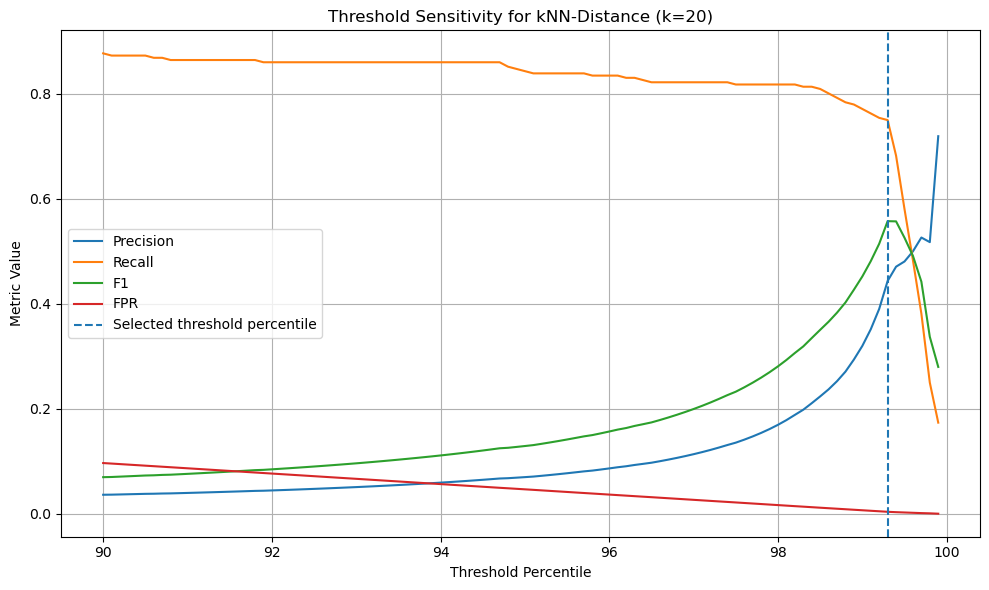

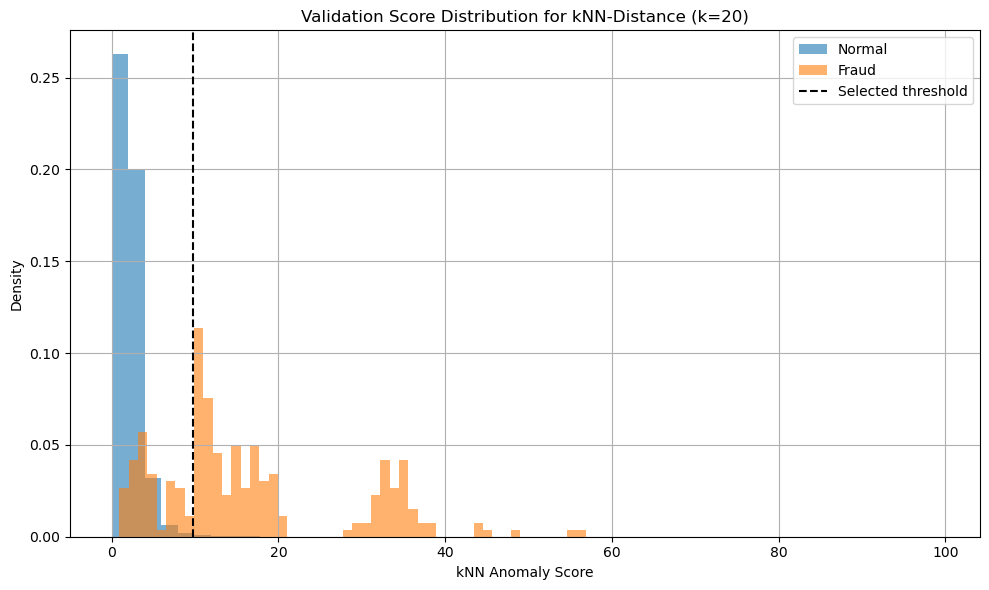

In [10]:
# Plot metric-vs-threshold curves
# Identify stable operating range

# Pick best k by validation F1
best_k = None
best_f1 = -1

for k, df_res in results_by_k.items():
    curr_best_f1 = df_res["f1"].max()
    if curr_best_f1 > best_f1:
        best_f1 = curr_best_f1
        best_k = k

print("Selected best k:", best_k)

val_results = results_by_k[best_k]

# Threshold candidates
conservative_row = val_results[val_results["precision"] == val_results["precision"].max()].iloc[0]
balanced_row = val_results.loc[val_results["f1"].idxmax()]
aggressive_row = val_results[val_results["recall"] == val_results["recall"].max()].iloc[0]

threshold_candidates = pd.DataFrame([
    {
        "type": "Conservative",
        "percentile": conservative_row["percentile"],
        "threshold": conservative_row["threshold"],
        "precision": conservative_row["precision"],
        "recall": conservative_row["recall"],
        "f1": conservative_row["f1"],
        "fpr": conservative_row["fpr"]
    },
    {
        "type": "Balanced",
        "percentile": balanced_row["percentile"],
        "threshold": balanced_row["threshold"],
        "precision": balanced_row["precision"],
        "recall": balanced_row["recall"],
        "f1": balanced_row["f1"],
        "fpr": balanced_row["fpr"]
    },
    {
        "type": "Aggressive",
        "percentile": aggressive_row["percentile"],
        "threshold": aggressive_row["threshold"],
        "precision": aggressive_row["precision"],
        "recall": aggressive_row["recall"],
        "f1": aggressive_row["f1"],
        "fpr": aggressive_row["fpr"]
    }
])

display(threshold_candidates)

selected_threshold = balanced_row["threshold"]
selected_percentile = balanced_row["percentile"]

print("\nSelected threshold for final test evaluation:")
print("Percentile:", selected_percentile)
print("Threshold :", selected_threshold)


# sensitivity curves:
plt.figure(figsize=(10, 6))
plt.plot(val_results["percentile"], val_results["precision"], label="Precision")
plt.plot(val_results["percentile"], val_results["recall"], label="Recall")
plt.plot(val_results["percentile"], val_results["f1"], label="F1")
plt.plot(val_results["percentile"], val_results["fpr"], label="FPR")
plt.axvline(selected_percentile, linestyle="--", label="Selected threshold percentile")
plt.xlabel("Threshold Percentile")
plt.ylabel("Metric Value")
plt.title(f"Threshold Sensitivity for kNN-Distance (k={best_k})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "knn_threshold_sensitivity.png"))
plt.show()

# Score dist:
scores_val = val_scores_by_k[best_k]

plt.figure(figsize=(10, 6))
plt.hist(scores_val[y_val == 0], bins=50, alpha=0.6, label="Normal", density=True)
plt.hist(scores_val[y_val == 1], bins=50, alpha=0.6, label="Fraud", density=True)
plt.axvline(selected_threshold, color="black", linestyle="--", label="Selected threshold")
plt.xlabel("kNN Anomaly Score")
plt.ylabel("Density")
plt.title(f"Validation Score Distribution for kNN-Distance (k={best_k})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "knn_score_distribution.png"))
plt.show()

In [11]:
# AD-09 standardized scoring API
def package_threshold_results(scores, threshold):
    pred_label = (scores >= threshold).astype(int)
    return pd.DataFrame({
        "anomaly_score": scores,
        "pred_label": pred_label,
        "threshold": threshold
    })

knn_val_output = package_threshold_results(val_scores_by_k[best_k], selected_threshold)
knn_test_output = package_threshold_results(test_scores_by_k[best_k], selected_threshold)

print("kNN validation output:")
display(knn_val_output.head())

print("kNN test output:")
display(knn_test_output.head())

kNN validation output:


,anomaly_score,pred_label,threshold
0,1.658945,0,9.732895
1,1.089469,0,9.732895
2,0.896576,0,9.732895
3,2.129161,0,9.732895
4,3.249929,0,9.732895


kNN test output:


,anomaly_score,pred_label,threshold
0,5.185272,0,9.732895
1,1.373701,0,9.732895
2,1.493096,0,9.732895
3,3.086635,0,9.732895
4,1.763922,0,9.732895


# 6) Required Evaluation Outputs


,method,threshold,precision,recall,f1,fpr
0,kNN-distance (k=20),9.732895,0.450122,0.780591,0.570988,0.003989


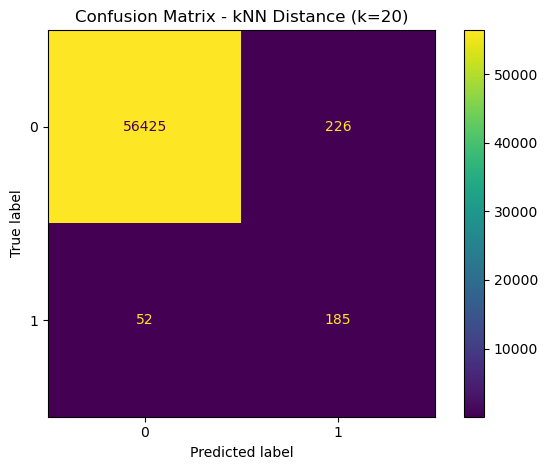

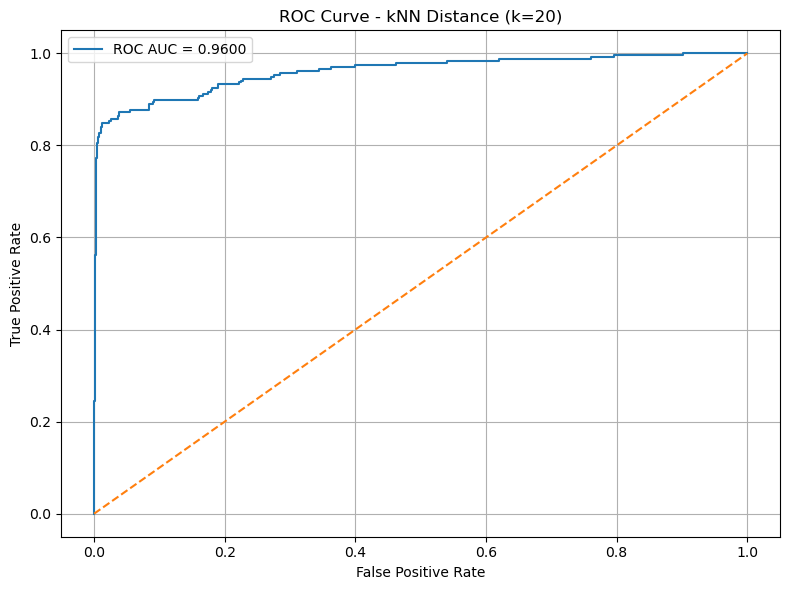

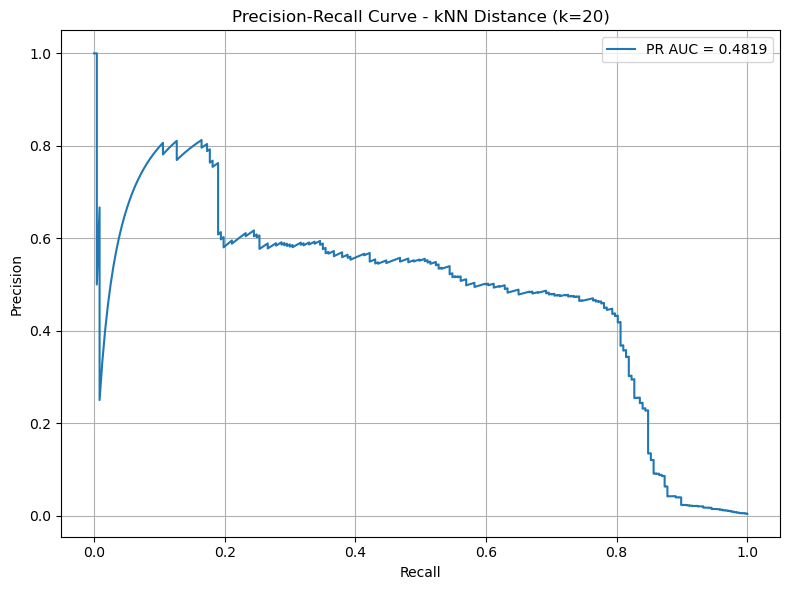

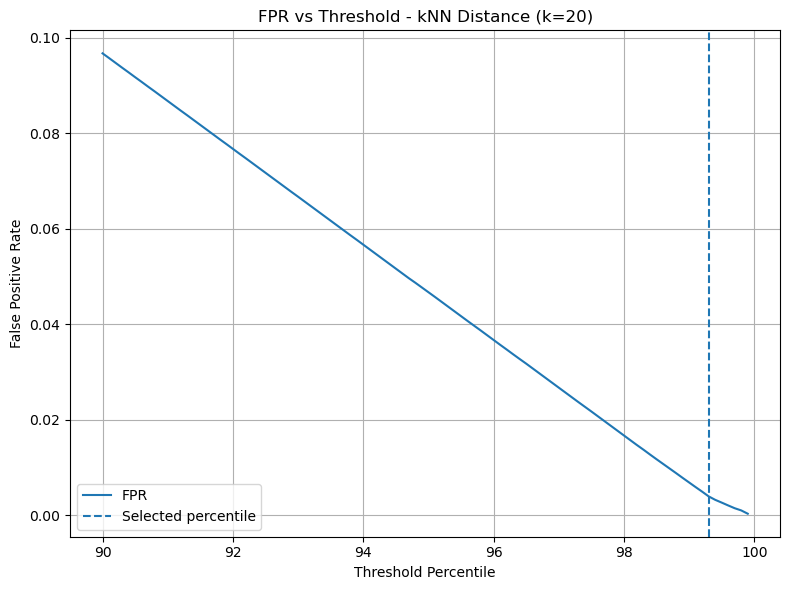

,eps,min_samples,precision,recall,f1,fpr,n_predicted_anomalies
9,3.0,3,0.031778,0.805085,0.061142,0.102187,5979
10,3.0,5,0.029255,0.838983,0.056539,0.115973,6768
11,3.0,10,0.026643,0.898305,0.051751,0.136714,7957
6,2.5,3,0.020541,0.855932,0.040119,0.170023,9834
7,2.5,5,0.018613,0.898305,0.036470,0.197313,11390
8,2.5,10,0.016525,0.936441,0.032476,0.232176,13374
3,2.0,3,0.012861,0.889831,0.025355,0.284532,16329
4,2.0,5,0.011619,0.932203,0.022953,0.330338,18934
5,2.0,10,0.010195,0.970339,0.020178,0.392456,22462
0,1.5,3,0.008718,0.944915,0.017277,0.447565,25578


In [12]:
# Confusion matrix at selected threshold
# ROC, PR curves and AUCs

test_scores = test_scores_by_k[best_k]
y_test_pred = (test_scores >= selected_threshold).astype(int)

test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_cm = confusion_matrix(y_test, y_test_pred)
test_fpr = compute_fpr(y_test, y_test_pred)

final_metrics_df = pd.DataFrame([{
    "method": f"kNN-distance (k={best_k})",
    "threshold": selected_threshold,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
    "fpr": test_fpr
}])

display(final_metrics_df)

# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=test_cm)
disp.plot()
plt.title(f"Confusion Matrix - kNN Distance (k={best_k})")
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "knn_confusion_matrix.png"))
plt.show()

# ROC Curve:
fpr_vals, tpr_vals, _ = roc_curve(y_test, test_scores)
roc_auc = roc_auc_score(y_test, test_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr_vals, tpr_vals, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - kNN Distance (k={best_k})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "knn_roc_curve.png"))
plt.show()

#PR Curve:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, test_scores)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - kNN Distance (k={best_k})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "knn_pr_curve.png"))
plt.show()

# FPR vs threshold plot
plt.figure(figsize=(8, 6))
plt.plot(val_results["percentile"], val_results["fpr"], label="FPR")
plt.axvline(selected_percentile, linestyle="--", label="Selected percentile")
plt.xlabel("Threshold Percentile")
plt.ylabel("False Positive Rate")
plt.title(f"FPR vs Threshold - kNN Distance (k={best_k})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, "knn_fpr_vs_threshold.png"))
plt.show()

# DBSCAN
display(dbscan_results_df)

## Final Evaluation

After selecting the threshold on the validation set, the threshold was fixed and applied once to the test set. Final performance was then evaluated using a confusion matrix, ROC curve, PR curve, and summary metrics including precision, recall, F1-score, and false positive rate.

Because the fraud dataset is highly imbalanced, the **precision-recall curve** is especially important for understanding model usefulness. The ROC curve is also reported to show the detectors ranking ability across all possible thresholds.

# 7) Hand-off Artifacts for Team


In [13]:
# Save plots/tables for final comparison section
threshold_candidates.to_csv(os.path.join(TABLE_PATH, "knn_threshold_candidates.csv"), index=False)
val_results.to_csv(os.path.join(TABLE_PATH, f"knn_threshold_sweep_k{best_k}.csv"), index=False)
final_metrics_df.to_csv(os.path.join(TABLE_PATH, "knn_final_test_metrics.csv"), index=False)
dbscan_results_df.to_csv(os.path.join(TABLE_PATH, "dbscan_validation_results.csv"), index=False)
knn_val_output.to_csv(os.path.join(TABLE_PATH, "knn_val_standardized_output.csv"), index=False)
knn_test_output.to_csv(os.path.join(TABLE_PATH, "knn_test_standardized_output.csv"), index=False)
dbscan_val_output.to_csv(os.path.join(TABLE_PATH, "dbscan_val_standardized_output.csv"), index=False)

print("Saved:")
print("- Threshold candidates")
print("- Full threshold sweep table")
print("- Final kNN test metrics")
print("- DBSCAN validation comparison table")
print("- All figures in:", FIG_PATH)


Saved:
- Threshold candidates
- Full threshold sweep table
- Final kNN test metrics
- DBSCAN validation comparison table
- All figures in: ../../artifacts/figures/


## Results

Among the tested k values, the **kNN-distance model with k = 20** produced the best overall validation performance and was selected for final evaluation. The threshold sensitivity analysis showed the expected tradeoff between recall and false positives. At lower threshold percentiles, the detector captured more fraudulent transactions but also flagged more normal transactions as anomalies. As the threshold increased, the false positive rate steadily decreased, while recall gradually declined. The selected operating point was located near the **99.4th percentile**, which appeared to provide the best balanced tradeoff.

The validation score distribution also showed clear separation between the normal and fraud classes. Most normal transactions were concentrated at relatively low kNN anomaly scores, while fraudulent transactions were shifted toward larger distances and extended much farther into the high-score region. Although some overlap remained, the selected threshold was placed in a region that captured a meaningful portion of the fraudulent cases while excluding most normal transactions.

On the held-out test set, the selected kNN-distance detector achieved a **ROC AUC of 0.9600** and a **PR AUC of 0.4819**, indicating strong ranking performance and moderate precision-recall performance under severe class imbalance. The confusion matrix showed **56,425 true negatives, 226 false positives, 52 false negatives, and 185 true positives**. This corresponds to a **precision of 0.450**, **recall of 0.781**, **F1-score of 0.571**, and **false positive rate of 0.0040**. 

These results suggest that the kNN-distance detector is effective at identifying a large fraction of fraudulent transactions while keeping the false positive rate very low. However, the precision value shows that many flagged transactions are still false alarms, which is expected in a highly imbalanced fraud setting. Overall, the selected threshold provides a reasonable operating point for a fraud-screening system where detecting suspicious activity is important and a small number of false alarms can be tolerated.

## Interpretation and Limitations

The selected kNN-distance detector achieved strong ranking performance, with ROC AUC = 0.9600 and PR AUC = 0.4819. The chosen threshold kept the false positive rate low while still detecting most fraud cases. However, precision remained moderate, meaning that many flagged transactions were still false alarms. This makes the method useful as a screening tool rather than a final decision system.